** Exercise 1**
 Task 1:Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image

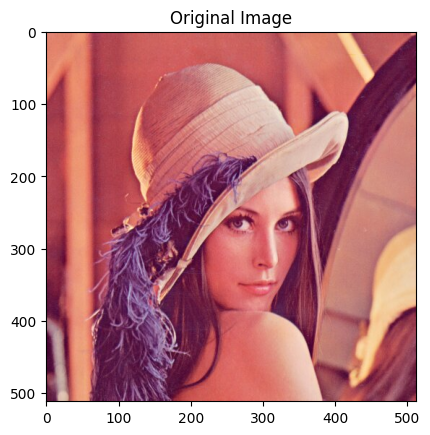

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("/content/drive/MyDrive/content/lenna.jpg")

plt.imshow(img)
plt.title("Original Image")
plt.show()

Task2:  Display only the top left corner of 100x100 pixels.
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing

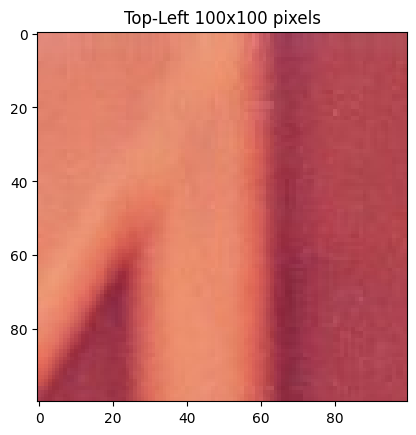

In [3]:

img_array = np.array(img)
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top-Left 100x100 pixels")
plt.show()

Task 3: Show the three color channels (R, G, B).
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

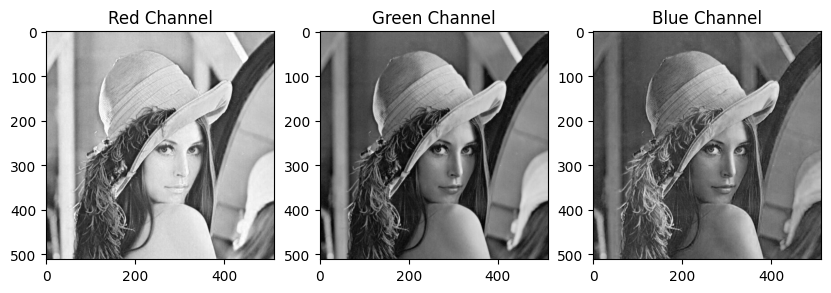

In [4]:

R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(10,4))

plt.subplot(1, 3, 1)
plt.imshow(R, cmap='gray')
plt.title("Red Channel")

plt.subplot(1, 3, 2)
plt.imshow(G, cmap='gray')
plt.title("Green Channel")

plt.subplot(1, 3, 3)
plt.imshow(B, cmap='gray')
plt.title("Blue Channel")

plt.show()

Task4:Modify the top 100 ×100 pixels to a value of 210 and display the resulting image:
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image

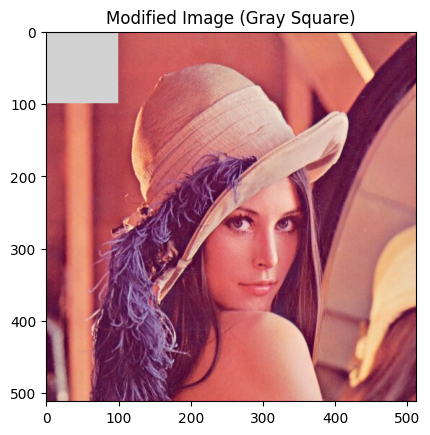

In [5]:
modified_img = img_array.copy()

modified_img[0:100, 0:100] = 210

plt.imshow(modified_img)
plt.title("Modified Image (Gray Square)")
plt.show()

**Exercise 2**
Task1:Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib

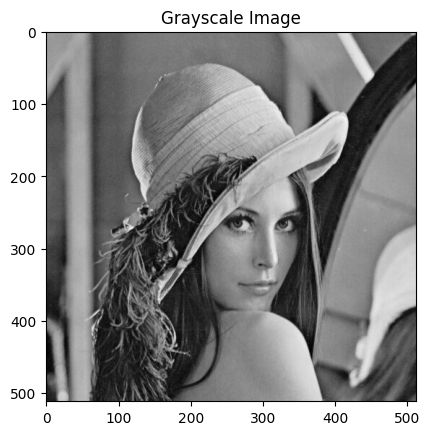

In [6]:

img_gray = Image.open("/content/drive/MyDrive/content/lenna.jpg").convert('L')

gray_array = np.array(img_gray)

plt.imshow(gray_array, cmap='gray')
plt.title("Grayscale Image")
plt.show()


Task2: Extract and display the middle section of the image (150 pixels).
• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib

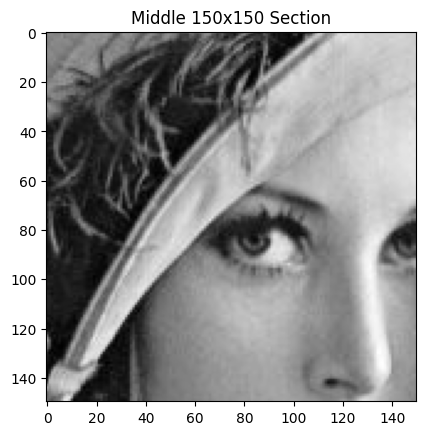

Shape of the section: (150, 150)


In [7]:

h, w = gray_array.shape

center_h = h // 2
center_w = w // 2

middle_section = gray_array[center_h-75 : center_h+75, center_w-75 : center_w+75]

plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.show()

print("Shape of the section:", middle_section.shape)

Task3: Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
• Display the resulting binary image

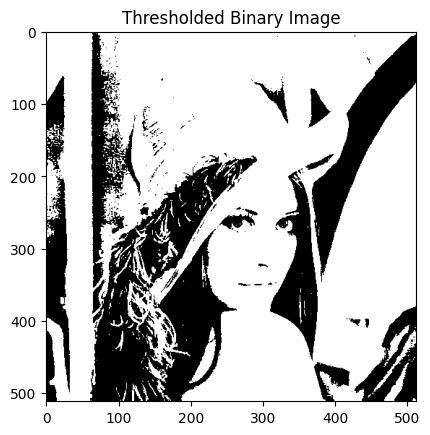

In [8]:

threshold_img = gray_array.copy()

threshold_img = gray_array.copy()
threshold_img[threshold_img < 100] = 0
threshold_img[threshold_img >= 100] = 255

plt.imshow(threshold_img, cmap='gray')
plt.title("Thresholded Binary Image")
plt.show()

Task4:  Rotate the image 90 degrees clockwise and display the result.
• Rotatethe image by90degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib

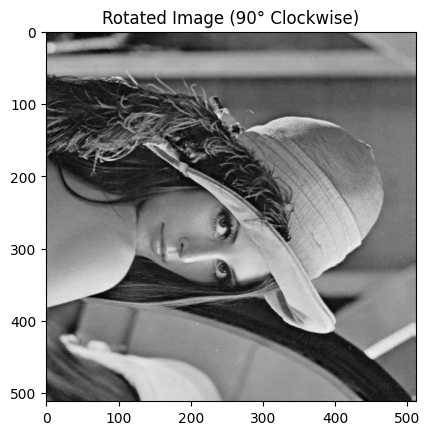

In [9]:
rotated_img = np.rot90(gray_array, k=-1)

plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated Image (90° Clockwise)")
plt.show()

Task5: Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib

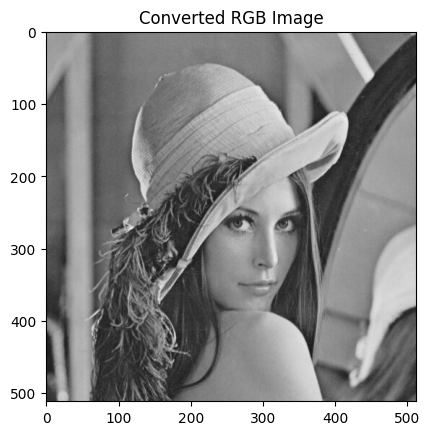

New Shape: (512, 512, 3)


In [10]:
rgb_converted = np.stack([gray_array, gray_array, gray_array], axis=-1)

plt.imshow(rgb_converted)
plt.title("Converted RGB Image")
plt.show()
print("New Shape:", rgb_converted.shape)

** Image Compression and Decompression using PCA **
 Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}
• Center the dataset- Standaridze the Data.
• Calculate the covaraince matrix of the Standaridze data

In [11]:
img= Image.open("/content/drive/MyDrive/content/lenna.jpg").convert('L')
img_arr = np.array(img)

mean_val = np.mean(img_arr, axis=0)
standardized_data = img_arr - mean_val

cov_matrix = np.cov(standardized_data, rowvar=False)

Task2:  Eigen Decomposition and Identifying Principal Components:
• Compute Eigen Values and Eigen Vectors.
• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.
• Identify the Principal Components with the help of cumulative Sum plot.

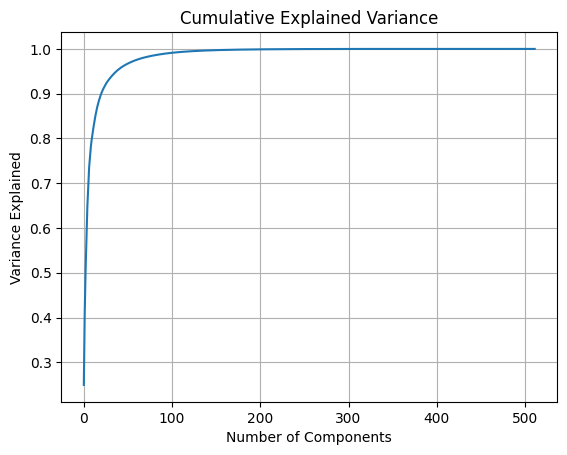

In [12]:
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.flip(np.argsort(eigen_values))
sorted_eigenvalues = eigen_values[sorted_indices]
sorted_eigenvectors = eigen_vectors[:, sorted_indices]

cumulative_sum = np.cumsum(sorted_eigenvalues) / np.sum(sorted_eigenvalues)
plt.plot(cumulative_sum)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance Explained")
plt.grid()
plt.show()

Task 3: Reconstruction and Experiment:
• Reconstruction: Transform the original data by multiplying it with the selected eigenvec
tors(PCs) to obtain a lower-dimensional representation.
• Experiments: Pick Four different combination of principal components with various ex
plained variance value and compare the result.
• Display the Results and Evaluate

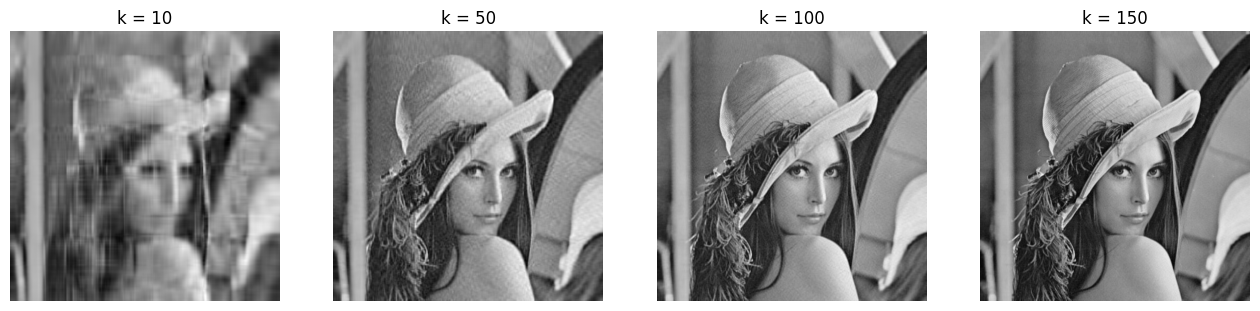

In [13]:
k_values = [10, 50, 100, 150]
plt.figure(figsize=(16, 4))

for i, k in enumerate(k_values):
    subset_vectors = sorted_eigenvectors[:, :k]
    compressed = np.dot(standardized_data, subset_vectors)
    reconstructed = np.dot(compressed, subset_vectors.T) + mean_val

    plt.subplot(1, 4, i + 1)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis('off')

plt.show()